# 1D Autonomous ODE

In [1]:
# import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import os
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set_style("whitegrid")
from model import *
from torch.utils.data import DataLoader, Dataset

torch.set_default_dtype(torch.float64)

## Read Data and Process Data

In [2]:
#Read data from .csv file
approx_sol = pd.read_csv('eg2_sol.csv', sep=',')
approx_solut = approx_sol.to_numpy()

#Data properties
components = 1 #spatial dimensions
deltat = 0.04
t = np.arange(0, 1, deltat)
time_steps = len(t)
n_initial_cond = approx_solut.shape[0] #number of initial conditions for solutions

#Read True RHS from .csv file
true_der = pd.read_csv('eg2_true_RHS.csv', sep=',')
true_der = true_der.to_numpy()

#Read Difference Quotients from .csv file
Diff_quot = pd.read_csv('eg2_app_RHS.csv', sep=',')
Diff_quot = Diff_quot.to_numpy()

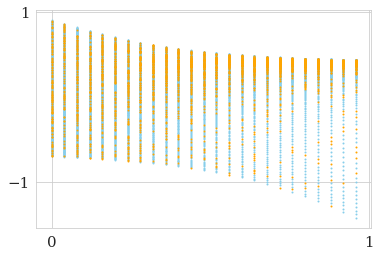

In [3]:
# Append t and x(t)
t_copy = np.tile(t, n_initial_cond).reshape(-1,1)
x_t = approx_solut.reshape(-1,1) 
inputs = np.append(t_copy, x_t, axis=1)
targets = Diff_quot.reshape(-1,1)

# train-test split 
X_train, X_test, Y_train, Y_test = train_test_split(inputs, targets, test_size=0.2)

# visualization
fontsize=15
plt.scatter(X_train[:,0], X_train[:,1], color='skyblue', s=1)
plt.scatter(X_test[:,0], X_test[:,1], color='orange', s=1)
plt.xticks([0,1], size = fontsize, fontname = 'serif')
plt.yticks([-1,1], size = fontsize, fontname = 'serif')
plt.show()

In [4]:
class LoadDataset(Dataset):
    def __init__(self, inputs, targets):
        self.x = inputs
        self.y = targets

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        inputs = self.x[idx, :]
        targets = self.y[idx, :]

        return inputs, targets

## Generate Non-trajectory Data

In [5]:
n = 100 #grid points where we do the recovery

# Define real RHS
def z_func(t,x):
    return np.cos(3*x) + x**3 - x

#define recovery domain boundaries
x_low = -0.7
x_top = 0.9
t_low = 0
t_top = 1.

#generate grid of x and t in the recovery domain
x = np.linspace(x_low, x_top, n)
time1 = np.linspace(t_low, t_top, n)
T,X = np.meshgrid(time1,x)

#compute true RHS on grid
Z = z_func(T, X)

#Generate input for netowrk
new_X = X.reshape(-1,1)
new_T = T.reshape(-1,1)
X_new = np.append(new_T,new_X,axis = 1)
net_input = torch.from_numpy(X_new)

## Define and train Lipschitz Neural Network

In [6]:
epochs = 15
batch_size = 100
input_size = 2 #columns in input matrix point
hidden_size = 64
output_size = 1 

# Network
gamma = 3
Lipschitz_network = LipNN(input_size,hidden_size,hidden_size, output_size, gamma)

#load dataset to use when training 
dataset = LoadDataset(torch.from_numpy(X_train), torch.from_numpy(Y_train))
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True) 
#select Optimizer and parameters
optimizer = torch.optim.Adam(Lipschitz_network.parameters(), lr=1e-2, betas=(0.9, 0.999), eps=1e-08, weight_decay=0.0, amsgrad=False) 

loss = torch.nn.MSELoss()

train_loss = []

for epoch in range(epochs):
    
    for input_data, targets in dataloader:
        preds = Lipschitz_network(input_data) 
        l2_loss = loss(preds, targets)
        
        #optimizer step
        optimizer.zero_grad()
        l2_loss.backward()
        optimizer.step()
        
    y_pred = Lipschitz_network(torch.from_numpy(X_train))
    train_loss.append( loss(y_pred, torch.from_numpy(Y_train)).item() )

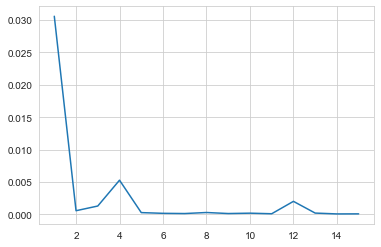

In [7]:
plt.plot(range(1,epochs+1),train_loss)

In [8]:
print('Lipschitz Neural Network: ')

# Compute training loss
y_pred = Lipschitz_network(torch.from_numpy(X_train))
Lipschitz_train_loss = loss(y_pred, torch.from_numpy(Y_train))
print('Training loss is {:.2e}'.format(Lipschitz_train_loss))

y_pred = Lipschitz_network(torch.from_numpy(X_test))
Lipschitz_test_loss = loss(y_pred, torch.from_numpy(Y_test))
print('Test loss is {:.2e}'.format(Lipschitz_test_loss))

# generalization gap
Lip_gap = Lipschitz_test_loss - Lipschitz_train_loss
print('Generalization gap is {:.2e}'.format(Lip_gap))

# Lipschitz Neural Network
Z_lip = Lipschitz_network(net_input).detach().numpy()
Z_lip = Z_lip.reshape(n,n)
print('Mean Relative Error on non-trajectory data {0:1.2f}%'.format(100*np.mean(abs(Z - Z_lip))/(np.abs(np.max(Z)-np.min(Z)))))


Lipschitz Neural Network: 
Training loss is 9.80e-05
Test loss is 9.65e-05
Generalization gap is -1.44e-06
Mean Relative Error on non-trajectory data 1.19%


## Define and train Neural Network with Lip-regularization

In [9]:
epochs = 15
batch_size = 100
input_size = 2 #columns in input matrix point
hidden_size1 = 10
hidden_size2 = 30
output_size = 1 
reg_param = 0.005

how_many_points = 10

# Neural Network with Lip-regulariation term
Lip_reg = LipNet(input_size,hidden_size1,hidden_size2, output_size)

#load dataset to use when training 
dataset = LoadDataset(torch.from_numpy(X_train), torch.from_numpy(Y_train))
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True) 
#select Optimizer and parameters
optimizer = torch.optim.Adam(Lip_reg.parameters(), lr=1e-2, betas=(0.9, 0.999), eps=1e-08, weight_decay=0.0, amsgrad=False) 

loss = torch.nn.MSELoss()
train_loss = []

for epoch in range(epochs):
    
    for input_data, targets in dataloader:
        preds = Lip_reg(input_data) 
        l2_loss = loss(preds, targets)
        Lips =  reg_param * Lip(input_data, how_many_points, Lip_reg)
        lo = l2_loss +  Lips
        
        #optimizer step
        optimizer.zero_grad()
        lo.backward()
        optimizer.step()
        
    y_pred = Lip_reg(torch.from_numpy(X_train))
    train_loss.append( loss(y_pred, torch.from_numpy(Y_train)).item())

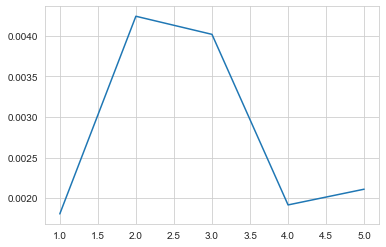

In [10]:
plt.plot(range(1,epochs+1),train_loss)

In [11]:
print('Lipschitz Regularized Neural Network')

# Compute training loss
y_pred = Lip_reg(torch.from_numpy(X_train))
Lip_reg_train_loss = loss(y_pred, torch.from_numpy(Y_train))
print('Training loss is {:.2e}'.format(Lip_reg_train_loss))

y_pred = Lip_reg(torch.from_numpy(X_test))
Lip_reg_test_loss = loss(y_pred, torch.from_numpy(Y_test))
print('Test loss is {:.2e}'.format(Lip_reg_test_loss))

# generalization gap
Lip_reg_gap = Lip_reg_test_loss - Lip_reg_train_loss
print('Generalization gap is {:.2e}'.format(Lip_reg_gap))

# Neural Network with Lip regularization
Z_reg = Lip_reg(net_input).detach().numpy()
Z_reg = Z_reg.reshape(n,n)
print('Mean Relative Error on non-trajectory data is {0:1.2f}%'.format(100*np.mean(abs(Z - Z_reg))/(np.abs(np.max(Z)-np.min(Z)))))

Lipschitz Regularized Neural Network
Training loss is 2.11e-03
Test loss is 2.05e-03
Generalization gap is -5.75e-05
Mean Relative Error on non-trajectory data is 2.67%


## Define Random Features

In [36]:
############## Model 1: regularization parameter is 0.0001

T = 50    # repeat random sampling 10 times

N = 50
sigma = 0.5
reg_param = 0.0001

Lip_const = 0

RF_train = np.zeros(T)
RF_test = np.zeros(T)
RF_gap = np.zeros(T)
RF_rel = np.zeros(T)

for t in range(T):
    
    # generate random features
    W = np.random.randn(2,N) / sigma
    b = np.random.uniform(0, 2*np.pi, size=(N,))
    
    # compute random features matrix and coefficients
    A = np.cos(X_train @ W + b) * np.sqrt(2/N)
    c = np.linalg.solve(A.T@A + reg_param * np.diag(np.linalg.norm(W,axis=0)), A.T@Y_train)
    
    # estimate Lipschitz constant
    Lip_const = Lip_const + np.sum( np.abs(c.reshape(-1)) * np.linalg.norm(W,axis=0) )
    
    # training loss
    y_pred = A @ c
    RF_train[t] = np.mean((y_pred - Y_train)**2)
    
    # test loss
    A_test = np.cos(X_test @ W + b) * np.sqrt(2/N)
    y_test = A_test @ c
    RF_test[t] = np.mean((y_test - Y_test)**2)

    # generalization gap
    RF_gap[t] = RF_test[t] - RF_train[t]
    
    # compute mean-relative error on non-trajectory data
    A = np.cos(X_new @ W + b) * np.sqrt(2/N)
    Z_RF = A @ c
    Z_RF = Z_RF.reshape(n,n)
    RF_rel[t] = np.mean(abs(Z - Z_RF))/ np.abs(np.max(Z)-np.min(Z))
    

print('Random Features:')
print(f'Training loss is {np.mean(RF_train):.2e}')
print(f'Test loss is {np.mean(RF_test):.2e}')
print(f'Generalization gap is {np.mean(RF_gap):.2e}')
print('Mean Relative Error on non-trajectory data is {0:1.2f}%'.format(100*np.mean(RF_rel)))
print('Estimated Lipschitz constant is {:.4f}'.format(Lip_const/T))

Random Features:
Training loss is 8.23e-06
Test loss is 7.33e-06
Generalization gap is -8.99e-07
Mean Relative Error on non-trajectory data is 1.09%
Estimated Lipschitz constant is 124.7724


In [37]:
############## Model 1: regularization parameter is 0.0001

T = 50    # repeat random sampling 10 times

N = 50
sigma = 0.5
reg_param = 0.001

Lip_const = 0

RF_train = np.zeros(T)
RF_test = np.zeros(T)
RF_gap = np.zeros(T)
RF_rel = np.zeros(T)

for t in range(T):
    
    # generate random features
    W = np.random.randn(2,N) / sigma
    b = np.random.uniform(0, 2*np.pi, size=(N,))
    
    # compute random features matrix and coefficients
    A = np.cos(X_train @ W + b) * np.sqrt(2/N)
    c = np.linalg.solve(A.T@A + reg_param * np.diag(np.linalg.norm(W,axis=0)), A.T@Y_train)
    
    # estimate Lipschitz constant
    Lip_const = Lip_const + np.sum( np.abs(c.reshape(-1)) * np.linalg.norm(W,axis=0) )

    # training loss
    y_pred = A @ c
    RF_train[t] = np.mean((y_pred - Y_train)**2)
    
    # test loss
    A_test = np.cos(X_test @ W + b) * np.sqrt(2/N)
    y_test = A_test @ c
    RF_test[t] = np.mean((y_test - Y_test)**2)

    # generalization gap
    RF_gap[t] = RF_test[t] - RF_train[t]
    
    # compute mean-relative error on non-trajectory data
    A = np.cos(X_new @ W + b) * np.sqrt(2/N)
    Z_RF = A @ c
    Z_RF = Z_RF.reshape(n,n)
    RF_rel[t] = np.mean(abs(Z - Z_RF))/ np.abs(np.max(Z)-np.min(Z))
    

print('Random Features:')
print(f'Training loss is {np.mean(RF_train):.2e}')
print(f'Test loss is {np.mean(RF_test):.2e}')
print(f'Generalization gap is {np.mean(RF_gap):.2e}')
print('Mean Relative Error on non-trajectory data is {0:1.2f}%'.format(100*np.mean(RF_rel)))
print('Estimated Lipschitz constant is {:.4f}'.format(Lip_const/T))

Random Features:
Training loss is 1.47e-05
Test loss is 1.29e-05
Generalization gap is -1.82e-06
Mean Relative Error on non-trajectory data is 1.11%
Estimated Lipschitz constant is 72.9446


In [38]:
############## Model 1: regularization parameter is 0.0001

T = 50    # repeat random sampling 10 times

N = 50
sigma = 0.5
reg_param = 0.01

Lip_const = 0

RF_train = np.zeros(T)
RF_test = np.zeros(T)
RF_gap = np.zeros(T)
RF_rel = np.zeros(T)

for t in range(T):
    
    # generate random features
    W = np.random.randn(2,N) / sigma
    b = np.random.uniform(0, 2*np.pi, size=(N,))
    
    # compute random features matrix and coefficients
    A = np.cos(X_train @ W + b) * np.sqrt(2/N)
    c = np.linalg.solve(A.T@A + reg_param * np.diag(np.linalg.norm(W,axis=0)), A.T@Y_train)
    
    # estimate Lipschitz constant
    Lip_const = Lip_const + np.sum( np.abs(c.reshape(-1)) * np.linalg.norm(W,axis=0) )

    # training loss
    y_pred = A @ c
    RF_train[t] = np.mean((y_pred - Y_train)**2)
    
    # test loss
    A_test = np.cos(X_test @ W + b) * np.sqrt(2/N)
    y_test = A_test @ c
    RF_test[t] = np.mean((y_test - Y_test)**2)

    # generalization gap
    RF_gap[t] = RF_test[t] - RF_train[t]
    
    # compute mean-relative error on non-trajectory data
    A = np.cos(X_new @ W + b) * np.sqrt(2/N)
    Z_RF = A @ c
    Z_RF = Z_RF.reshape(n,n)
    RF_rel[t] = np.mean(abs(Z - Z_RF))/ np.abs(np.max(Z)-np.min(Z))
    

print('Random Features:')
print(f'Training loss is {np.mean(RF_train):.2e}')
print(f'Test loss is {np.mean(RF_test):.2e}')
print(f'Generalization gap is {np.mean(RF_gap):.2e}')
print('Mean Relative Error on non-trajectory data is {0:1.2f}%'.format(100*np.mean(RF_rel)))
print('Estimated Lipschitz constant is {:.4f}'.format(Lip_const/T))

Random Features:
Training loss is 2.75e-05
Test loss is 2.41e-05
Generalization gap is -3.46e-06
Mean Relative Error on non-trajectory data is 1.17%
Estimated Lipschitz constant is 50.6728


In [39]:
############## Model 1: regularization parameter is 0.0001

T = 50    # repeat random sampling 10 times

N = 50
sigma = 0.5
reg_param = 0

Lip_const = 0

RF_train = np.zeros(T)
RF_test = np.zeros(T)
RF_gap = np.zeros(T)
RF_rel = np.zeros(T)

for t in range(T):
    
    # generate random features
    W = np.random.randn(2,N) / sigma
    b = np.random.uniform(0, 2*np.pi, size=(N,))
    
    # compute random features matrix and coefficients
    A = np.cos(X_train @ W + b) * np.sqrt(2/N)
    c = np.linalg.solve(A.T@A + reg_param * np.diag(np.linalg.norm(W,axis=0)), A.T@Y_train)

    # estimate Lipschitz constant
    Lip_const = Lip_const + np.sum( np.abs(c.reshape(-1)) * np.linalg.norm(W,axis=0) )
    
    # training loss
    y_pred = A @ c
    RF_train[t] = np.mean((y_pred - Y_train)**2)
    
    # test loss
    A_test = np.cos(X_test @ W + b) * np.sqrt(2/N)
    y_test = A_test @ c
    RF_test[t] = np.mean((y_test - Y_test)**2)

    # generalization gap
    RF_gap[t] = RF_test[t] - RF_train[t]
    
    # compute mean-relative error on non-trajectory data
    A = np.cos(X_new @ W + b) * np.sqrt(2/N)
    Z_RF = A @ c
    Z_RF = Z_RF.reshape(n,n)
    RF_rel[t] = np.mean(abs(Z - Z_RF))/ np.abs(np.max(Z)-np.min(Z))
    

print('Random Features:')
print(f'Training loss is {np.mean(RF_train):.2e}')
print(f'Test loss is {np.mean(RF_test):.2e}')
print(f'Generalization gap is {np.mean(RF_gap):.2e}')
print('Mean Relative Error on non-trajectory data is {0:1.2f}%'.format(100*np.mean(RF_rel)))
print('Estimated Lipschitz constant is {:.4f}'.format(Lip_const/T))

Random Features:
Training loss is 3.44e-06
Test loss is 3.37e-06
Generalization gap is -7.22e-08
Mean Relative Error on non-trajectory data is 2.92%
Estimated Lipschitz constant is 1511513.7014
